<a href="https://colab.research.google.com/github/amperry01/CPSC393-spotify-recommender/blob/main/spotify_recommender_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPSC 393 Final Project: Spotify Recommender
---

**Team Members:** Brooke England and Alyssa Perry

**Project Goal:** Develop a Spotify music recommendation system based on audio feature similarity (energy, tempo, danceability). The project focuses on implementing and comparing existing methods - specifically KNN (Euclidean/cosine) and K-means clustering - to analyze how algorithm selection and feature engineering impact recommendation performance.

**Dataset:** https://www.kaggle.com/datasets/vatsalmavani/spotify-dataset?select=data

**Evaluated Models:**

1. K-Nearest Neighbors
    <ol type="a">
      <li>Euclidean Distance</li>
      <li>Cosine Similarity</li>
    </ol>
2. K-Means Clustering
3. DBSCAN Clustering

## Setup and Data Preparation

### 1. Setup and Imports

In [1]:
# connects google drive to notebook since using a shard drive folder
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

Mounted at /content/drive


### 2. Load Dataset

The dataset we will be using is a Spotify dataset from Kaggle. It contains audio features to describe the key characteristics of songs. The dataset is publicly available, and we will access it by loading it as a CSV file from Kaggle and processing it using Python libraries such as Pandas and NumPy.



In [2]:
# file path for data
data_path = '/content/drive/MyDrive/CPSC393_FinalProject/data/data.csv'

# load dataset
data = pd.read_csv(data_path)

# show first rows
data.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [3]:
# shape of data
data.shape

(170653, 19)

There are 170,653 rows and 19 columns

### 3. Initial Data Evaluation

In [4]:
# column names
for col in data.columns:
  print(col)

valence
year
acousticness
artists
danceability
duration_ms
energy
explicit
id
instrumentalness
key
liveness
loudness
mode
name
popularity
release_date
speechiness
tempo


In [5]:
# get data types
data.dtypes

,0
valence,float64
year,int64
acousticness,float64
artists,object
danceability,float64
duration_ms,int64
energy,float64
explicit,int64
id,object
instrumentalness,float64


In [6]:
# check for missing values
data.isna().sum()

,0
valence,0
year,0
acousticness,0
artists,0
danceability,0
duration_ms,0
energy,0
explicit,0
id,0
instrumentalness,0


No missing values in the dataset

In [7]:
# check for duplicate rows
data.duplicated().sum()

np.int64(0)

No duplicate rows in the dataset

#### Summary Statistics

In [8]:
# get summary statistics
data.describe()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,5.199844,0.205839,-11.467990,0.706902,31.431794,0.098393,116.861590
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,3.515094,0.174805,5.697943,0.455184,21.826615,0.162740,30.708533
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,2.000000,0.098800,-14.615000,0.000000,11.000000,0.034900,93.421000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,5.000000,0.136000,-10.580000,1.000000,33.000000,0.045000,114.729000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,8.000000,0.261000,-7.183000,1.000000,48.000000,0.075600,135.537000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,100.000000,0.970000,243.507000


### 4. Data Cleaning

In [9]:
data = data.drop_duplicates(subset=['name', 'artists'])

# remove audiobook / non-song entries
data = data[~data['name'].str.contains('Chapter|Часть|Part', case=False, na=False)]

data = data.reset_index(drop=True)

The dataset was mostly clean, with no missing values or exact duplicate rows. However, we found multiple entries for the same song due to differences in metadata such as track ID and popularity. These duplicates negatively impacted recommendation quality, so we removed them based on song name and artist to ensure each song is only represented once.

In addition, we identified non-music audio content (such as audiobook-style tracks) based on naming patterns (e.g., “Part”/“Часть”), repeated author names, and nearly identical feature values. These entries were not representative of typical songs and caused the model to return unintuitive recommendations, so they were removed to improve overall recommendation quality.

### 5. Exploratory Data Analysis (EDA)

#### Feature Distributions

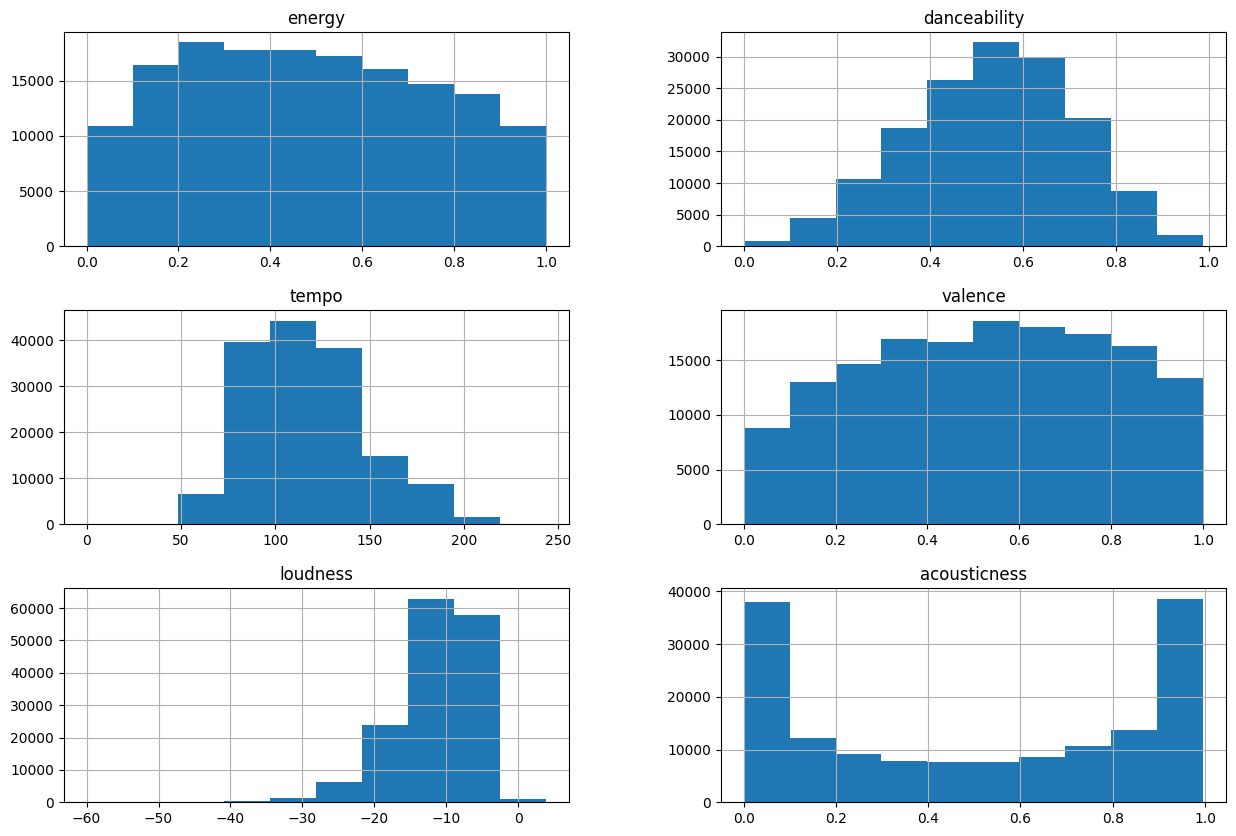

In [10]:
# distribution of key features
key_features = ['energy', 'danceability', 'tempo', 'valence', 'loudness', 'acousticness']
data[key_features].hist(figsize=(15, 10))
plt.show()

**Feature Distributions:**
- Most features (energy, danceability, valence) are evenly distributed, indicating good variability in the dataset
- Tempo is concentrated in a typical musical range (~90–130 BPM), with a few high-tempo outliers
- Loudness is skewed toward higher values

**Patterns:**
- Acousticness has a bimodal distribution (two distinct peaks), suggesting two distinct groups of songs: highly acoustic and non-acoustic
- Danceability and energy are centered around moderate values, meaning extreme values are less common

**Implications:**
- Features like acousticness may help separate distinct song types (useful for classification/clustering).
- Skewed features (loudness, acousticness) may benefit from transformation or careful scaling

#### Correlation Analysis

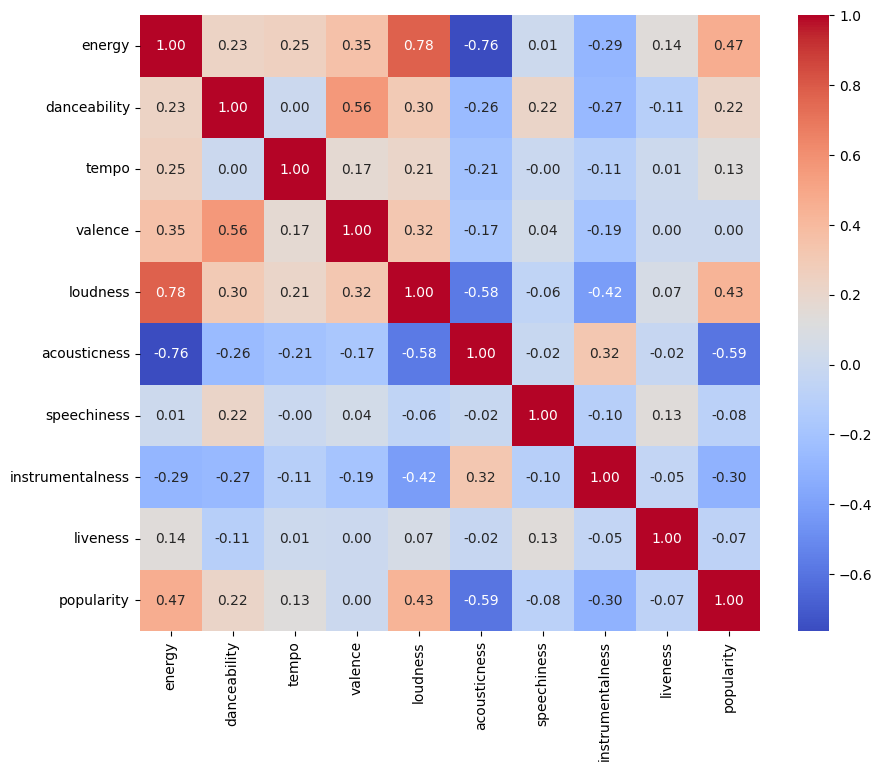

In [11]:
# get correlation between numeric features (excluding extra noisy features and categorical features)
corr_features = [
    'energy', 'danceability', 'tempo', 'valence', 'loudness',
    'acousticness', 'speechiness', 'instrumentalness',
    'liveness', 'popularity'
]

corr = data[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

**Insights**:
- Energy and loudness have a strong positive correlation (0.78), indicating that louder songs tend to be more energetic
- Acousticness is strongly negatively correlated with both energy (-0.75) and loudness (-0.56), suggesting that acoustic songs tend to be low energy and quieter
- Popularity shows moderate positive correlations with energy (0.49) and loudness (0.46), and a slightly stronger negative correlation with acousticness (-0.57), indicating that more popular songs tend to be louder, more energetic, and less acoustic
- Danceability and valence are moderately correlated (0.56), suggesting that more danceable songs are generally more positive in mood
- Other features such as tempo, liveness, and speechiness show weak correlations with most variables

#### Trends and Bias

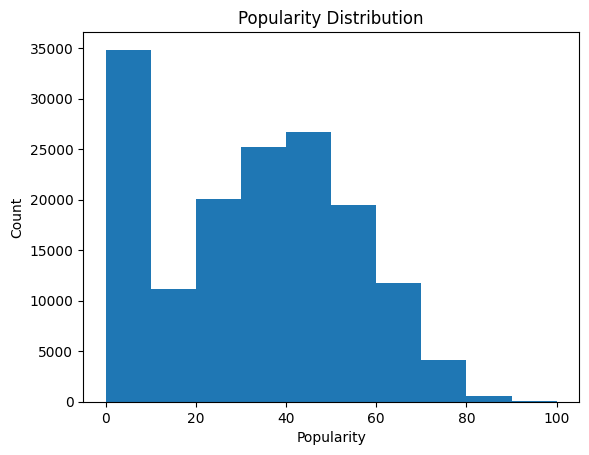

In [12]:
# popularity distribution
plt.hist(data['popularity'])
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

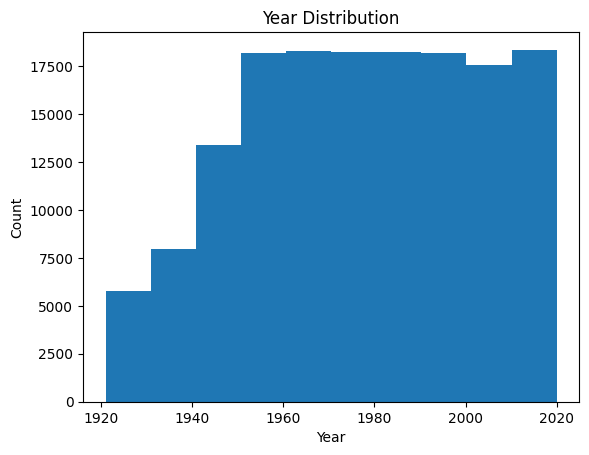

In [13]:
# year distribution
plt.hist(data['year'])
plt.title("Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

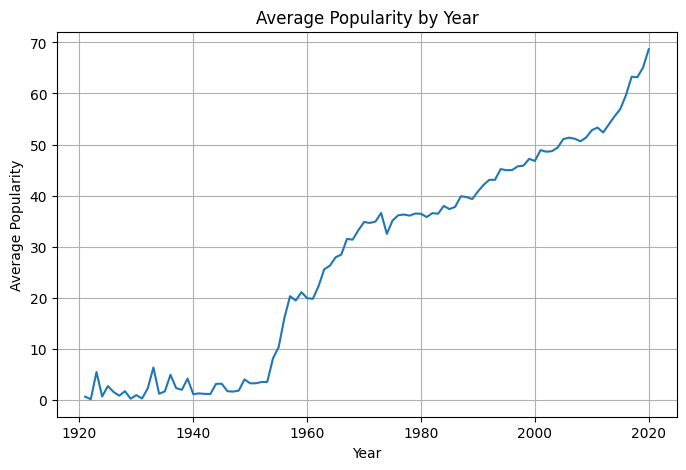

In [14]:
# average popularity by year
avg_popularity = data.groupby('year')['popularity'].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_popularity.index, avg_popularity.values)
plt.title("Average Popularity by Year")
plt.xlabel("Year")
plt.ylabel("Average Popularity")
plt.grid()
plt.show()

**Insights**:
- The popularity distribution shows an imbalance, with clusters of both low-popularity and moderately popular songs
- The year distribution indicates that songs are evenly spread across years, although there is a slight concentration in more recent years
- The average popularity by year shows a strong upward trend, with newer songs having significantly higher popularity than older ones

**Conclusion**:
- These results suggest a recency bias in the dataset, where newer songs tend to be more popular. This may influence the model to favor recent songs when predicting popularity


#### Takeaways

Below are some key takeaways based on our initial exploratory data analysis:
- Energy and loudness are highly correlated, so they may provide redundant information.
- Popularity is higher for louder, more energetic, and less acoustic songs, making these strong predictors.
- Most other features are weakly correlated, meaning they add useful independent information.
- Popularity increases over time, indicating a recency bias that may cause the model to favor newer songs.
- Overall, the model may be biased toward predicting higher popularity for newer, high-energy, non-acoustic songs

### 6. Feature Selection

Since this project focuses on building a similarity-based recommendation system, feature selection was guided by identifying variables that best represent the musical characteristics of songs. Because KNN, KMeans, and DBSCAN rely on distance calculations, it is important to include features that meaningfully describe song similarity while avoiding irrelevant or redundant variables

The following audio features were selected:

In [15]:
features = [
    'energy', 'danceability', 'tempo', 'valence',
    'acousticness', 'speechiness',
    'instrumentalness', 'liveness'
]

These features were chosen because they capture key aspects of a song’s sound, including intensity, rhythm, mood, and acoustic properties, which are essential for determining similarity between songs

**Removed Features:**
- Non-informative identifiers: id, name, artists, release_date
- Non-audio or biased features: popularity, year
- Categorical or weak features: key, mode, explicit
- Redundant features: loudness (highly correlated with energy)
- Less relevant: duration_ms

### 7. Data Preprocessing

In [16]:
# feature matrix using selected features
X = data[features]

# check feature matrix
X.head()

,energy,danceability,tempo,valence,acousticness,speechiness,instrumentalness,liveness
0,0.211,0.279,80.954,0.0594,0.982,0.0366,0.878000,0.665
1,0.341,0.819,60.936,0.9630,0.732,0.4150,0.000000,0.160
2,0.166,0.328,110.339,0.0394,0.961,0.0339,0.913000,0.101
3,0.309,0.275,100.109,0.1650,0.967,0.0354,0.000028,0.381
4,0.193,0.418,101.665,0.2530,0.957,0.0380,0.000002,0.229


In [17]:
# scale features for distance based comparisons
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# convert scaled data to dataframe
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# check scaled features
X_scaled_df.head()

,energy,danceability,tempo,valence,acousticness,speechiness,instrumentalness,liveness
0,-1.029217,-1.448167,-1.170051,-1.768684,1.263316,-0.388205,2.247669,2.618063
1,-0.542325,1.613176,-1.821467,1.647575,0.600000,2.531522,-0.539489,-0.259064
2,-1.197757,-1.170379,-0.213819,-1.844298,1.207598,-0.409038,2.358774,-0.595204
3,-0.662175,-1.470844,-0.546719,-1.369439,1.223517,-0.397464,-0.539401,1.000035
4,-1.096633,-0.660155,-0.496084,-1.036736,1.196985,-0.377403,-0.539484,0.134048


In [18]:
# check scaling (mean ~ 0 and std ~ 1)
X_scaled_df.describe()

,energy,danceability,tempo,valence,acousticness,speechiness,instrumentalness,liveness
count,1.540210e+05,1.540210e+05,1.540210e+05,1.540210e+05,1.540210e+05,1.540210e+05,1.540210e+05,1.540210e+05
mean,-1.653401e-16,1.136713e-16,-3.424903e-16,-1.306482e-16,-3.897303e-16,-3.247752e-17,4.281128e-17,2.288189e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.819481e+00,-3.029861e+00,-3.804416e+00,-1.993258e+00,-1.342192e+00,-6.706101e-01,-5.394894e-01,-1.170629e+00
25%,-8.382057e-01,-6.941699e-01,-7.626643e-01,-8.098929e-01,-1.071559e+00,-4.013223e-01,-5.394894e-01,-6.088774e-01
50%,-3.670639e-02,5.415844e-02,-6.673184e-02,3.698849e-02,5.607982e-02,-3.249341e-01,-5.386513e-01,-4.014963e-01
75%,8.247181e-01,7.344569e-01,6.104893e-01,8.347205e-01,1.037789e+00,-1.034855e-01,-1.744288e-01,3.106639e-01
max,1.925843e+00,2.571263e+00,4.119667e+00,1.787462e+00,1.300462e+00,6.806175e+00,2.634951e+00,4.526652e+00


Since KNN, K-Means, and DBSCAN rely on distance calculations, we scaled the selected features so that larger-scale variables like tempo don't dominate distance calculations. StandardScaler transforms each feature to have a mean of 0 and standard deviation of 1, making the features more comparable for similarity-based modeling.

We verified the scaling with summary statistics, showing that each feature has a mean close to 0 and a standard deviation of 1. Standardization was applied correctly.

### 8. Recommendation Helper Functions

To keep things organized, we created a helper function that takes in a song name and returns similar songs. This lets us reuse the same function across different models instead of rewriting the logic each time.

The function finds the selected song in the dataset, gets its index, and then uses the model to generate recommendations. For KNN models, it returns the closest songs based on distance in the feature space. For clustering models like K-Means and DBSCAN, it returns songs from the same cluster or dense region.

We also added an optional era filter, which restricts recommendations to songs from a similar time period as the input. This helps make results feel slightly more realistic by avoiding extreme cross-era matches.

This keeps the code cleaner and makes it easier to compare results across models.

In [19]:
def get_era(year):
  if year < 1970:
      return "pre-1970"
  elif year < 1990:
      return "1970-1989"
  elif year < 2010:
      return "1990-2009"
  else:
      return "2010+"

data['era'] = data['year'].apply(get_era)

In [20]:
def get_recommendations(song_name, model, X_scaled, data, model_type="knn", use_era=False):
  matches = data[data['name'].str.lower() == song_name.lower()]

  if matches.empty:
    return f"Song '{song_name}' not found in dataset."

  song_index = matches.index[0]

  # era filter logic
  if use_era:
    song_era = data.loc[song_index, 'era']
    subset = data[data['era'] == song_era]
    subset_indices = subset.index
  else:
    subset = data
    subset_indices = data.index

  # knn
  if model_type == "knn":
    if use_era:
        song_era = data.loc[song_index, 'era']
        subset = data[data['era'] == song_era]
        subset_indices = subset.index.tolist()

        X_subset = X_scaled[subset_indices]

        # find position of song in subset
        subset_position = subset_indices.index(song_index)

        # fit a temp model on subset
        temp_model = NearestNeighbors(n_neighbors=6, metric=model.metric)
        temp_model.fit(X_subset)

        distances, indices = temp_model.kneighbors([X_subset[subset_position]])
        rec_indices = [subset_indices[i] for i in indices[0]]

    else:
        distances, indices = model.kneighbors([X_scaled[song_index]])
        rec_indices = indices[0]

    recommendations = data.iloc[rec_indices][['name', 'artists']].iloc[1:].copy()
    recommendations['distance'] = distances[0][1:]

  # k means
  elif model_type == "kmeans":
    song_cluster = data.loc[song_index, 'cluster']

    recommendations = subset[(subset['cluster'] == song_cluster) & (subset.index != song_index)][['name', 'artists']].head(5).copy()

  # dbscan
  elif model_type == "dbscan":
    song_cluster = data.loc[song_index, 'dbscan_cluster']

    if song_cluster == -1:
      return "Input song was labeled as noise, so DBSCAN could not generate cluster-based recommendations."

    recommendations = subset[(subset['dbscan_cluster'] == song_cluster) & (subset.index != song_index)][['name', 'artists']].head(5).copy()

  else:
    return "Invalid model_type. Use 'knn' or 'kmeans'."

  recommendations = recommendations.reset_index(drop=True)
  return recommendations

## Models

### 1a. KNN with Euclidean Distance

KNN with Euclidean distance is our baseline model. It recommends songs by calculating the straight-line distance between the selected song and every other song in the scaled feature space. Songs with the smallest distances are treated as the most similar, so this gives us a simple starting point for comparing other recommendation methods.

In [21]:
# choose k (nearest neighbors) and initialize model
knn_euclidean = NearestNeighbors(n_neighbors=6, metric='euclidean')

# fit model on scaled features
knn_euclidean.fit(X_scaled)

NearestNeighbors(metric='euclidean', n_neighbors=6)

We selected k = 6 (the song itself + 5 recommendations) to prioritize highly similar songs. Smaller values of k tend to return more relevant recommendations, while larger values may introduce less similar songs.

In [22]:
get_recommendations("Lane Boy", knn_euclidean, X_scaled, data, model_type="knn")

,name,artists,distance
0,The Middle,['Jimmy Eat World'],0.243387
1,Do You Think I'm a Whore?,['Kittie'],0.315345
2,It's Gonna Be Me,['*NSYNC'],0.336883
3,Nappy Dugout,['Funkadelic'],0.362269
4,Woolly Bully,['Bad Manners'],0.387269


In [23]:
get_recommendations("Lane Boy", knn_euclidean, X_scaled, data, model_type="knn", use_era=True)

,name,artists,distance
0,Neon Light,['Blake Shelton'],0.395475
1,Lights Come On,['Jason Aldean'],0.403829
2,Throw Shade,['CRUISR'],0.427170
3,Next Girl,['Carly Pearce'],0.440167
4,Something to Believe In,['Citizen Cope'],0.456932


The Euclidean KNN model returns songs that are numerically similar to the input based on the selected audio features. In some cases, this gives pretty reasonable recommendations, but a lot of the time the results don’t really match what a listener would expect as “similar.”

For example, when using "Lane Boy" as input, the model returns older jazz and vocal tracks that don’t match the genre or overall vibe of the song. This happens because the model is only using low-level audio features like energy and tempo, which capture measurable properties of the music but don’t reflect higher-level characteristics like genre, style, or context.

This highlights a key limitation of Euclidean distance: it does a good job measuring similarity in feature space, but that doesn’t always line up with how people actually perceive musical similarity. So even if songs are mathematically close, they can still feel completely different.

We also considered including features like year and popularity, but decided not to use them since they introduce bias (like favoring newer or more popular songs) instead of capturing true musical similarity. Overall, this shows how difficult it is to represent something as subjective as music using only numerical features.

### 1b. KNN with Cosine Similarity

KNN with cosine similarity compares songs based on the angle between their feature vectors rather than straight-line distance. This focuses on the overall pattern of features (such as relative energy, danceability, and tempo) instead of their exact values. As a result, cosine similarity often captures more meaningful relationships in the data and can sometimes produce recommendations that better align with how listeners perceive similarity.

In [24]:
# choose k (nearest neighbors) and initialize model
knn_cosine = NearestNeighbors(n_neighbors=6, metric='cosine')

# fit model on scaled features
knn_cosine.fit(X_scaled)

NearestNeighbors(metric='cosine', n_neighbors=6)

In [25]:
get_recommendations("Lane Boy", knn_cosine, X_scaled, data, model_type="knn")

,name,artists,distance
0,The Middle,['Jimmy Eat World'],0.002404
1,It's Gonna Be Me,['*NSYNC'],0.002995
2,Guitars and Tiki Bars,['Kenny Chesney'],0.005481
3,The Tears of a Clown,['The Beat'],0.005519
4,Do You Think I'm a Whore?,['Kittie'],0.006047


In [26]:
get_recommendations("Lane Boy", knn_cosine, X_scaled, data, model_type="knn", use_era=True)

,name,artists,distance
0,Neon Light,['Blake Shelton'],0.009515
1,Lights Come On,['Jason Aldean'],0.009868
2,Throw Shade,['CRUISR'],0.010808
3,Next Girl,['Carly Pearce'],0.011453
4,Whistlin' Dixie,['Randy Houser'],0.012252


Cosine similarity compares songs based on the overall pattern of their audio features rather than their exact values, but the results still don’t consistently match what we would expect as “similar” from a listener’s perspective.

For example, when using "No Diggity" as input, the model returns a mix of pop, R&B, and international tracks. Some of these feel somewhat reasonable, but overall they’re still only loosely related. When using "Lane Boy" as input, the model returns older vocal and jazz songs like Frank Sinatra and Dinah Washington, which clearly don’t match the genre or style of the original song.

This happens because cosine similarity focuses on the relative proportions of features instead of their magnitude. So if two songs have similar patterns across features, they can be considered close even if they sound very different. Because of this, the model can group songs that are mathematically similar but not perceptually similar.

Overall, while cosine similarity can capture patterns in the data, it doesn’t fix the main issue of relying only on low-level audio features. Without higher-level information like genre, artist, or context, the model still struggles to produce recommendations that consistently feel intuitive.

### 2. K-Means Clustering

K-Means is an unsupervised learning algorithm that groups songs into clusters based on their similarity in the feature space. Instead of finding the nearest neighbors to a specific song, it assigns each song to a cluster, where songs in the same cluster are considered similar.

This provides a different approach compared to KNN, as it groups songs more broadly rather than focusing on exact pairwise similarity.

In [27]:
# choose k (clusters) and initialize model
kmeans = KMeans(n_clusters=20, random_state=42)

# fit model on scaled features
kmeans.fit(X_scaled)

KMeans(n_clusters=20, random_state=42)

In [28]:
# assign clusters to data
data['cluster'] = kmeans.labels_

In [29]:
get_recommendations("Lane Boy", kmeans, X_scaled, data, model_type="kmeans")

,name,artists
0,Chicago (That Toddlin' Town),['Jim Chapman']
1,Potato Head Blues,['Louis Armstrong & His Hot Seven']
2,Mississippi Mud (feat. Bix Beiderbecke),"['Paul Whiteman & His Orchestra', 'Bix Beiderb..."
3,(What Are You Waiting For) Mary,"['Paul Whiteman & His Orchestra', 'Bix Beiderb..."
4,Button Up Your Overcoat,"['The Chenille Sisters', ""James Dapogny's Chic..."


In [30]:
get_recommendations("Lane Boy", kmeans, X_scaled, data, model_type="kmeans", use_era=True)

,name,artists
0,The Lazy Song,['Bruno Mars']
1,Erase Me - Main,"['Kid Cudi', 'Kanye West']"
2,Down On Me,"['Jeremih', '50 Cent']"
3,Pretty Girl Rock,['Keri Hilson']
4,Boyfriend,['Big Time Rush']


The K-Means model groups songs into clusters based on their similarity in the feature space rather than finding the closest individual matches. Because of this, the recommendations tend to be broader and less precise compared to KNN.

For example, when using "Lane Boy" as input, the model returns older jazz songs that do not match the genre or overall style of the original track. Even after increasing the number of clusters to try to create more specific groupings, the results remained inconsistent and did not significantly improve.

This happens because K-Means treats all songs within a cluster as similar, even if they are not very close to each other. Unlike KNN, it does not prioritize the most similar songs, but instead returns any songs that fall into the same general group.

Overall, while K-Means provides a different perspective by grouping songs into broader categories, it lacks precision and still struggles to produce intuitive recommendations. Like the other models, it is limited by relying only on low-level audio features, which do not capture higher-level characteristics like genre, era, or cultural context.

### 3. DBSCAN Clustering

DBSCAN is an unsupervised clustering algorithm that groups songs based on density in the feature space. Instead of assigning every song to a fixed number of clusters, DBSCAN identifies dense regions as clusters and labels isolated points as noise.

This provides a different approach compared to K-Means because it does not require choosing the number of clusters ahead of time and can detect outliers.

In [31]:
# choose DBSCAN parameters and initialize model
dbscan = DBSCAN(eps=0.5, min_samples=5)

# fit model on scaled features
dbscan_labels = dbscan.fit_predict(X_scaled)

In [32]:
# assign DBSCAN clusters to data
data['dbscan_cluster'] = dbscan_labels

In [33]:
# check number of clusters and noise points
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Number of DBSCAN clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of DBSCAN clusters: 325
Number of noise points: 45929


In [34]:
get_recommendations("Lane Boy", dbscan, X_scaled, data, model_type="dbscan")

,name,artists
0,Gati Bali,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...
1,Danny Boy,['Frank Parker']
2,When Irish Eyes Are Smiling,['Phil Regan']
3,The Wearing of the Green,['John McCormack']
4,La Mañanita - Remasterizado,['Ignacio Corsini']


The DBSCAN model groups songs based on density in the feature space rather than assigning songs to a fixed number of clusters. Songs located in dense regions are grouped together, while isolated songs are labeled as noise or outliers.

For example, when using "Lane Boy" as input, DBSCAN returned songs that were still largely unrelated in genre or musical style to the original track. Many recommendations came from broad dense regions in the dataset rather than closely matching songs.

The model also identified a large number of noise points, suggesting that the Spotify audio features do not naturally form strong, well-separated clusters. This matches what we found in the initial data evaluation with the PCA plot. While DBSCAN provided a different clustering perspective compared to K-Means, it still struggled to generate intuitive music recommendations.

Overall, DBSCAN reinforced the same core limitation observed throughout the project: low-level audio features alone were not sufficient to capture higher-level musical characteristics such as genre, style, era, or overall vibe.

## Evaluation

### 1. Quantitative Comparison

In [35]:
# Calculate average distance for KNN Euclidean and KNN Cosine Similarity
def evaluate_knn(model, X_scaled, n_samples=100):
    distances_all = []

    for i in range(n_samples):
        distances, indices = model.kneighbors([X_scaled[i]])
        # exclude the first (itself)
        distances_all.extend(distances[0][1:])

    return np.mean(distances_all)

# evaluate both models
euclidean_score = evaluate_knn(knn_euclidean, X_scaled)
cosine_score = evaluate_knn(knn_cosine, X_scaled)

print("Average Distance (Euclidean):", euclidean_score)
print("Average Distance (Cosine):", cosine_score)

Average Distance (Euclidean): 0.4604377571249738
Average Distance (Cosine): 0.015191895724848508


In [46]:
# inertia (already computed)
print("K-Means Inertia:", kmeans.inertia_)

# silhouette score
sil_score_kmeans = silhouette_score(X_scaled, kmeans.labels_, sample_size=10000, random_state=42)
print("K-Means Silhouette Score:", sil_score_kmeans)

K-Means Inertia: 365276.3176180345
K-Means Silhouette Score: 0.1689377425315617


In [48]:
# clusters and noise (already computed)
print("DBSCAN Clusters:", n_clusters)
print("DBSCAN Noise:", n_noise)

# silhouette score
sil_score_dbscan = silhouette_score(X_scaled, dbscan.labels_, sample_size=10000, random_state=42)
print("K-Means Silhouette Score:", sil_score_dbscan)

DBSCAN Clusters: 325
DBSCAN Noise: 45929
K-Means Silhouette Score: -0.5080076469342254


To evaluate the performance of our recommendation models, we used quantitative metrics based on similarity and clustering quality. Since this is an unsupervised recommendation system, traditional accuracy metrics are not applicable. Instead, we focused on measuring how close or well-grouped the recommendations are in the feature space.

For the KNN models, we computed the average distance between each song and its nearest neighbors. Lower average distances indicate that the model is recommending songs that are more similar in terms of the selected audio features.

- The Euclidean KNN model produced an average distance of 0.46
- The Cosine similarity KNN model produced an average distance of 0.015

Although these values are on different scales, the cosine similarity model produced consistently smaller distances, indicating tighter grouping based on feature patterns. This suggests that cosine similarity is more effective at capturing similarity in the data compared to Euclidean distance.

For the K-Means model, we evaluated clustering performance using inertia and the silhouette score. Inertia measures how close points are to their assigned cluster center, while the silhouette score evaluates how well-separated clusters are.

- K-Means inertia: 365276.32
- Silhouette score: 0.169

The silhouette score of 0.169 indicates weak cluster separation, meaning that songs within the same cluster are not significantly more similar to each other than to songs in other clusters. This suggests that the clusters are not well-defined and that the feature space does not naturally separate into distinct groups.

For the DBSCAN model, we evaluated the number of detected clusters, noise points, and silhouette score.

- DBSCAN Clusters: 325
- DBSCAN Noise Points: 45929
- DBSCAN Silhouette Score: -0.508

The large number of noise points and negative silhouette score suggest that DBSCAN struggled to find meaningful density-based groupings in the Spotify feature space. This further supports the observation that the audio features did not naturally separate into strong, well-defined clusters.


### 2. Qualitative Examples

#### Example 1

In [50]:
song = "Blinding Lights"

euclidean_recs = get_recommendations(song, knn_euclidean, X_scaled, data, model_type="knn")
cosine_recs = get_recommendations(song, knn_cosine, X_scaled, data, model_type="knn")
kmeans_recs = get_recommendations(song, kmeans, X_scaled, data, model_type="kmeans")
dbscan_recs = get_recommendations(song, dbscan, X_scaled, data, model_type="dbscan")

In [51]:
comparison = pd.DataFrame({
    "Euclidean KNN": euclidean_recs['name'] + " - " + euclidean_recs['artists'],
    "Cosine KNN": cosine_recs['name'] + " - " + cosine_recs['artists'],
    "K-Means": kmeans_recs['name'] + " - " + kmeans_recs['artists'],
    "DBSCAN": dbscan_recs['name'] + " - " + dbscan_recs['artists']
})

comparison

,Euclidean KNN,Cosine KNN,K-Means,DBSCAN
0,Latin Simone (Que Pasa Contigo) - ['Gorillaz'],Latin Simone (Que Pasa Contigo) - ['Gorillaz'],Power Is Power - ['Zay Gatsby'],Gati Bali - ['KHP Kridhamardawa Karaton Ngayog...
1,Ren og rettferdig - ['Stagedive Live'],You Are Loved - ['Stars Go Dim'],Sad Song - ['Paul Bridgwater'],Danny Boy - ['Frank Parker']
2,Made in America - ['Toby Keith'],Ren og rettferdig - ['Stagedive Live'],Ditty Diego - ['White Flag'],When Irish Eyes Are Smiling - ['Phil Regan']
3,Sirens - ['The String Cheese Incident'],Made in America - ['Toby Keith'],Who Needs Summer? - ['The Haywains'],The Wearing of the Green - ['John McCormack']
4,"Be Happy - Remix - ['Dixie D’Amelio', 'blackbe...",Sirens - ['The String Cheese Incident'],Beyond All Fear - LOL Edit - ['Nomy'],La Mañanita - Remasterizado - ['Ignacio Corsini']


To compare model behavior, we generated recommendations for the same input song and examined the results side by side.

The Euclidean and cosine KNN models produced highly similar recommendations, with significant overlap between the suggested songs. For example, tracks such as “Latin Simone (Que Pasa Contigo)” by Gorillaz and “Made in America” by Toby Keith appeared in both models. This indicates that both distance metrics are identifying similar neighbors in the feature space. This overlap suggests that, for this dataset, the relative structure of the feature space is similar under both Euclidean and cosine distance, meaning the choice of distance metric has less impact than the choice of features.

However, despite this consistency, the recommendations span a wide range of genres and styles, including alternative, country, and electronic music. This suggests that while the models are finding songs that are numerically similar in terms of audio features, they are not capturing meaningful musical similarity from a listener’s perspective. This is a limitation based on the information available in the dataset, as we don't have available data on genre or region.

In contrast, the K-Means model produced completely different recommendations with no overlap with the KNN results. The suggested songs appeared more diverse and less consistent, with little overlap in artist, genre, or style compared to KNN results. This demonstrates the broader and less precise nature of clustering-based recommendations.

The DBSCAN model also struggled to generate meaningful recommendations. Many returned songs appeared unrelated to the original input, and the recommendations were heavily influenced by dense regions of the dataset rather than close musical similarity.

Overall, the comparison showed that KNN-based approaches produced the most consistent recommendations, while clustering-based methods such as K-Means and DBSCAN struggled to form intuitive music groupings using only low-level Spotify audio features.

#### Example 2

In [52]:
song = "Firework"

euclidean_recs = get_recommendations(song, knn_euclidean, X_scaled, data, model_type="knn")
cosine_recs = get_recommendations(song, knn_cosine, X_scaled, data, model_type="knn")
kmeans_recs = get_recommendations(song, kmeans, X_scaled, data, model_type="kmeans")
dbscan_recs = get_recommendations(song, dbscan, X_scaled, data, model_type="dbscan")

In [53]:
comparison = pd.DataFrame({
    "Euclidean KNN": euclidean_recs['name'] + " - " + euclidean_recs['artists'],
    "Cosine KNN": cosine_recs['name'] + " - " + cosine_recs['artists'],
    "K-Means": kmeans_recs['name'] + " - " + kmeans_recs['artists'],
    "DBSCAN": dbscan_recs['name'] + " - " + dbscan_recs['artists']
})

comparison

,Euclidean KNN,Cosine KNN,K-Means,DBSCAN
0,Nobody - ['The Doobie Brothers'],This Beat Goes On - Original Radio Seque - ['T...,Korkma Sönmez - ['Mehmet Kemiksiz'],Gati Bali - ['KHP Kridhamardawa Karaton Ngayog...
1,Godstar - ['Psychic TV'],Go Big Or Go Home - ['American Authors'],Baksana Kim Boynu Bükük Ağlayan - ['Mehmet Kem...,Danny Boy - ['Frank Parker']
2,The Love I Lost (feat. Teddy Pendergrass) - ['...,She's in Love with You - 2017 Remaster - ['Suz...,"Bottle of Wine - ['Why Not', 'Paul Bridgwater']",When Irish Eyes Are Smiling - ['Phil Regan']
3,Brand New Man - ['Brooks & Dunn'],Red - Original Demo Recording - ['Taylor Swift'],Setlogolo Saga Lekwadu - Jevido Del Cee. Vudoo...,The Wearing of the Green - ['John McCormack']
4,She's in Love with You - 2017 Remaster - ['Suz...,Chica de ayer - ['Nacha Pop'],Stupid - LOL Edit - ['Nomy'],La Mañanita - Remasterizado - ['Ignacio Corsini']


We also evaluated the models using “Firework” by Katy Perry, a mainstream pop song with a clear musical style.

Compared to previous examples, the KNN models produced slightly more reasonable recommendations. Some suggested songs, such as tracks by Taylor Swift, are closer to the pop genre and share more similarities with the original song.

However, the overall results remain inconsistent. The recommendations still include songs from a wide range of genres and eras, including classic rock, country, and international tracks. This indicates that while the models can occasionally capture partial similarity in audio features, they still fail to consistently reflect genre or stylistic coherence.

As in earlier examples, the Euclidean and cosine KNN models produced overlapping recommendations, demonstrating consistent behavior across distance metrics. In contrast, both clustering models struggled to generate meaningful recommendations. K-Means produced broad cluster-based suggestions, while DBSCAN returned songs that showed little stylistic connection to the input track.

Overall, this example reinforced the broader trend observed throughout the project: KNN-based methods produced more consistent recommendations, while clustering approaches struggled to capture intuitive musical similarity using only low-level Spotify audio features.

### 3. Visual Comparison

#### Dataset Structure

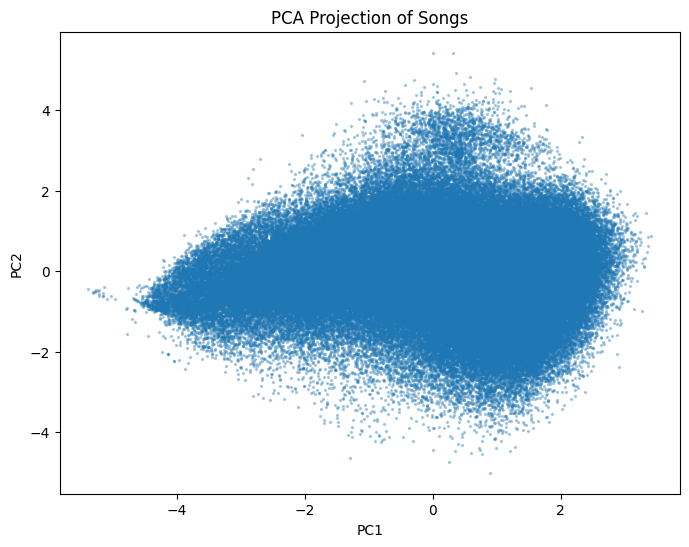

In [41]:
# PCA plot
# reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=2, alpha=0.3)
plt.title("PCA Projection of Songs")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### K-Means Clustering Behavior

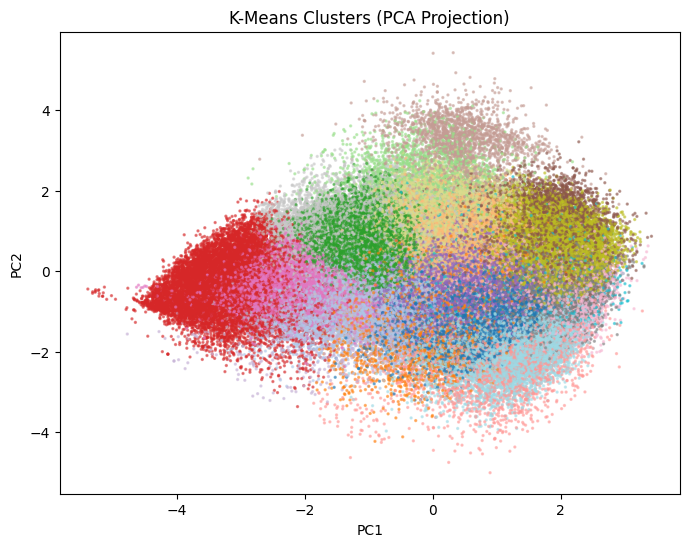

In [42]:
# PCA + kmeans clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans.labels_, s=2, cmap='tab20', alpha=0.5)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### DBSCAN Clustering Behavior

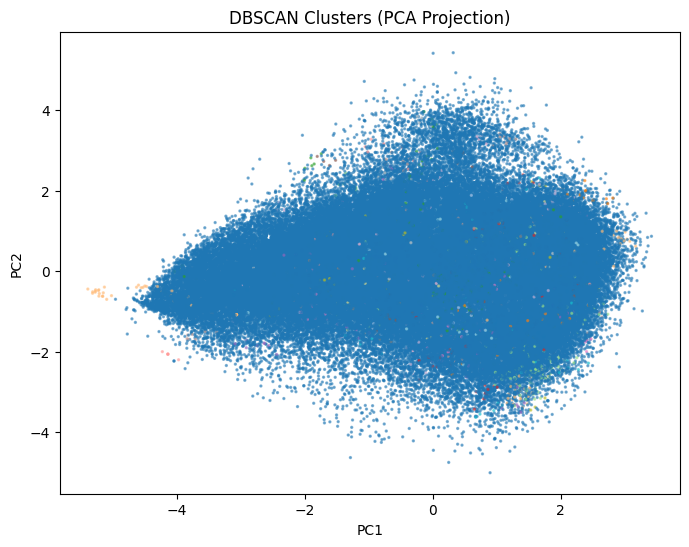

In [54]:
# PCA + dbscan clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan.labels_, s=2, cmap='tab20', alpha=0.5)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

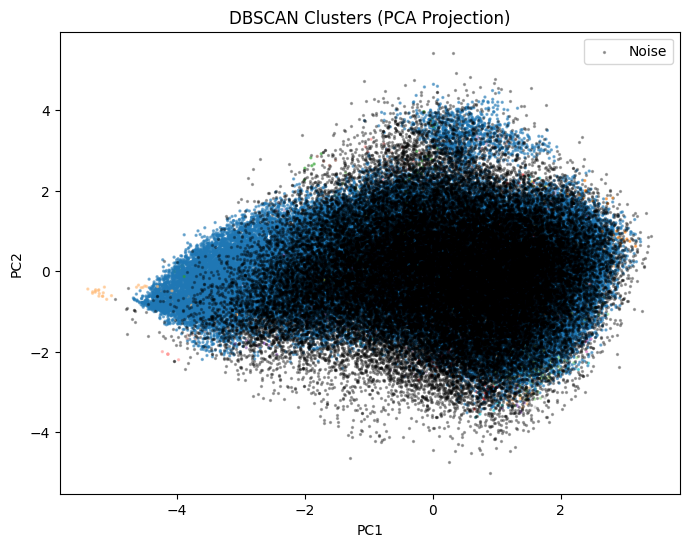

In [55]:
# visualize DBSCAN with noise highlighted
plt.figure(figsize=(8,6))

# noise points = black
noise = dbscan.labels_ == -1
clusters = dbscan.labels_ != -1

plt.scatter(
    X_pca[clusters,0],
    X_pca[clusters,1],
    c=dbscan.labels_[clusters],
    s=2,
    cmap='tab20',
    alpha=0.5
)

plt.scatter(
    X_pca[noise,0],
    X_pca[noise,1],
    c='black',
    s=2,
    alpha=0.3,
    label='Noise'
)

plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

#### KNN Recommendations (Euclidean and Era Filter Comparison)

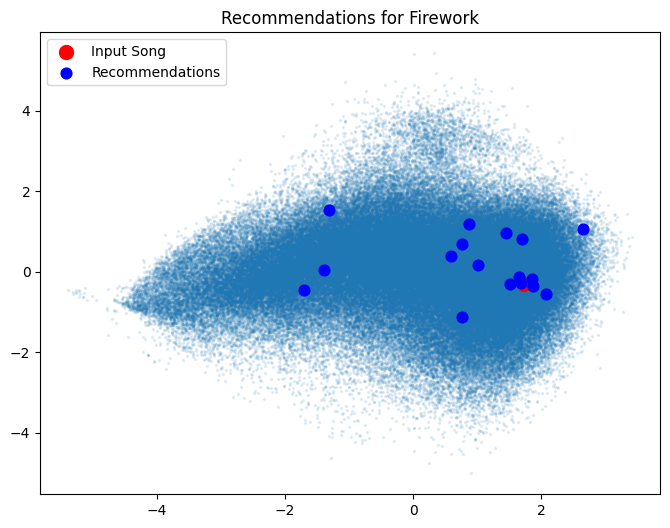

In [43]:
# specific song and recommendations
def plot_recommendations(song_name, model, X_scaled, data, use_era=False):
    recs = get_recommendations(song_name, model, X_scaled, data, model_type="knn", use_era=use_era)

    song_idx = data[data['name'].str.
    lower() == song_name.lower()].index[0]

    plt.figure(figsize=(8,6))

    # all songs
    plt.scatter(X_pca[:,0], X_pca[:,1], s=2, alpha=0.1)

    # highlight input song
    plt.scatter(X_pca[song_idx,0], X_pca[song_idx,1], color='red', s=100, label="Input Song")

    # highlight recommendations
    rec_indices = data[data['name'].isin(recs['name'])].index
    plt.scatter(X_pca[rec_indices,0], X_pca[rec_indices,1], color='blue', s=60, label="Recommendations")

    plt.title(f"Recommendations for {song_name}")
    plt.legend()
    plt.show()

plot_recommendations("Firework", knn_euclidean, X_scaled, data, False)

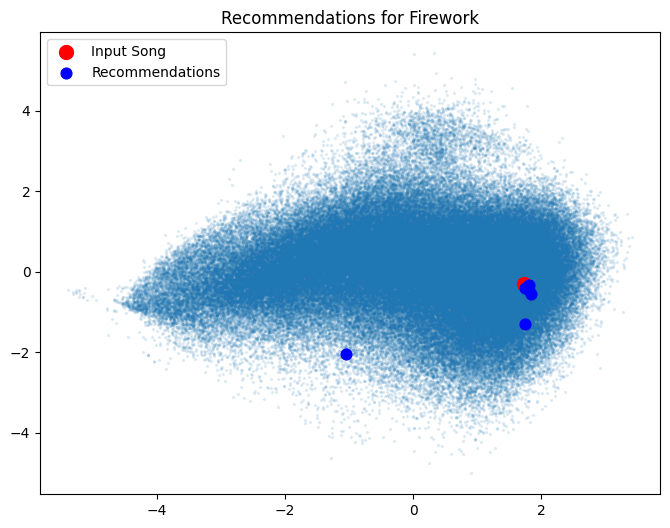

In [44]:
plot_recommendations("Firework", knn_euclidean, X_scaled, data, True)

Era filtering had a noticeable impact on the Euclidean KNN model, producing recommendations that were more localized and consistent within a similar time period. This suggests that constraining the dataset helps reduce variability in absolute feature values such as tempo and loudness.

However, while the recommendations are closer in feature space, they still do not necessarily align with expected genre or style. This reinforces that improving numerical proximity does not fully resolve the mismatch with human perception of similarity.

#### KNN Recommendations (Cosine Similarity)

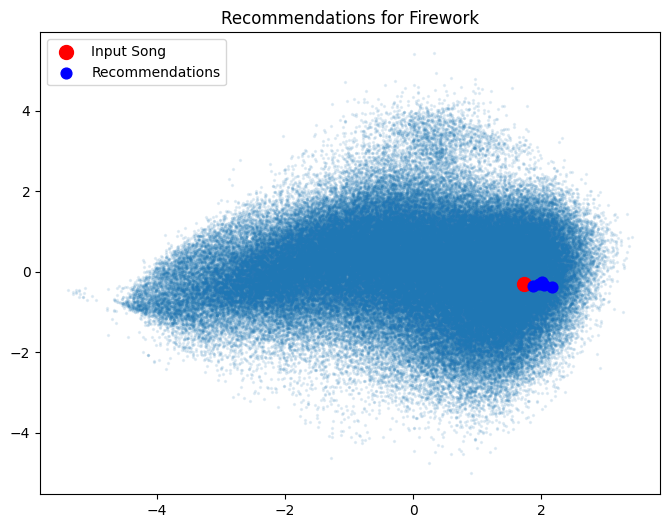

In [45]:
plot_recommendations("Firework", knn_cosine, X_scaled, data, False)

Compared to Euclidean distance, cosine similarity produces recommendations that are more tightly clustered around the input song in the feature space. This indicates that cosine similarity emphasizes relative feature patterns rather than absolute values.

When applying era filtering, the Euclidean model begins to show a similar clustering behavior, as restricting the dataset reduces variability in feature magnitudes. However, despite this convergence in spatial structure, neither approach consistently produces recommendations that align with expected genre or style.

This highlights that while different distance metrics and constraints can change how similarity is measured, they do not resolve the core limitation of relying only on low-level audio features.

#### Overall Visual Comparisons

Overall, the visualizations show that while the models are able to find songs that are close in feature space, this does not always match how people perceive musical similarity. The PCA plot shows that the data does not naturally separate into clear groups, which helps explain why K-Means struggles to form meaningful clusters.

KNN models do a better job identifying nearby songs, but these are often only similar in low-level audio features rather than genre or overall vibe. Adding constraints like era filtering can improve consistency and sometimes makes Euclidean behave more similarly to cosine, but it does not fully resolve the issue.

K-Means attempted to divide songs into broad clusters, but the clusters heavily overlapped in the reduced feature space. Similarly, DBSCAN struggled to identify clear dense regions in the dataset, labeling many songs as either part of one large group or as noise points. This suggests that the Spotify audio features do not naturally form well-separated musical communities.

The recommendation visualizations further highlight this gap. While recommended songs may appear close to the input in feature space, they are often spread across unrelated genres and styles. This reinforces that proximity in feature space does not necessarily correspond to human perception of similarity, and that the main limitation comes from the available features rather than the models themselves.

## Results and Conclusion

We evaluated three models for music recommendation: KNN (Euclidean and Cosine), K-Means clustering, and DBSCAN Clustering.

**Quantitative results** showed that KNN produced tighter similarity groupings than the clustering approaches. The cosine similarity KNN model had the lowest average distance, indicating better capture of feature patterns. K-Means performed poorly, with a low silhouette score (0.169), suggesting weak and overlapping clusters. DBSCAN identified many noise points and fragmented clusters, indicating that the datset does not contain string density-separated groupings.

**Qualitative results** showed that while KNN models were consistent, their recommendations often did not match genre, era or overall vibe. Songs from very different styles and time periods were frequently grouped together, indicating that similarity was being driven by low-level audio features rather than meaningful musical relationships. Cosine similarity slightly changed the behavior of KNN, but did not consistently improve recommendation quality.

**Visualizations** using Principal Component Analysis (PCA) supported these findings. The data forms a continuous space without clear separation into clusters, explaining why both K-Means and DBSCAN struggle. Recommendation plots showed that suggested songs are not close in feature space, but still spread out and not tightly grouped in a way that aligns with human perception of similarity.

Overall, changing the model type or tuning clustering behavior had less of an impact than expected. The main limitation comes from the feature set itself. While audio features capture measurable properties such as tempo and energy, they do not represent higher-level characteristics like genre, artist style, or cultural context. As a result, all models were able to find numerically similar songs, but failed to consistently produce intuitive recommendations.

Importantly, the models themselves did not fail. They correctly identified similarity based on the given low-level audio features, with the KNN models performing measurably better in this area. The problem is that these numerical similarities don’t always match how people perceive music, which highlights the gap between feature-based similarity and real-world interpretation.

**Future work** could include using higher-level features such as genre labels, artist similarity, or user-based data. Combining these with similarity-based methods would likely produce recommendations that align better with how listeners perceive music.